In [9]:

import os
import re
import nltk
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# Download Stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:


dataset_path = kagglehub.dataset_download(
    "andrewmvd/trip-advisor-hotel-reviews"
)

csv_path = os.path.join(
    dataset_path,
    "tripadvisor_hotel_reviews.csv"
)

hotel_reviews = pd.read_csv(csv_path)

print("First Five Records")
print(hotel_reviews.head())

print("\nDataset Shape :", hotel_reviews.shape)
print("\nColumns :", hotel_reviews.columns.tolist())

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.
First Five Records
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5

Dataset Shape : (20491, 2)

Columns : ['Review', 'Rating']


In [12]:
stop_words = set(stopwords.words("english"))

def clean_text(review):

    review = review.lower()

    review = re.sub(r"[^a-zA-Z\s]", " ", review)

    words = review.split()

    cleaned_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

hotel_reviews["Processed_Review"] = hotel_reviews["Review"].apply(clean_text)

print("\nCleaned Reviews")
print(hotel_reviews[["Review", "Processed_Review"]].head())




Cleaned Reviews
                                              Review  \
0  nice hotel expensive parking got good deal sta...   
1  ok nothing special charge diamond member hilto...   
2  nice rooms not 4* experience hotel monaco seat...   
3  unique, great stay, wonderful time hotel monac...   
4  great stay great stay, went seahawk game aweso...   

                                    Processed_Review  
0  nice hotel expensive parking got good deal sta...  
1  ok nothing special charge diamond member hilto...  
2  nice rooms experience hotel monaco seattle goo...  
3  unique great stay wonderful time hotel monaco ...  
4  great stay great stay went seahawk game awesom...  


                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None
Shape: (20491, 2)
Columns: Index(['Review', 'Rating'], dtype='object')


In [13]:

def get_sentiment(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"

hotel_reviews["Sentiment"] = hotel_reviews["Rating"].apply(get_sentiment)

print("\nSentiment Counts")
print(hotel_reviews["Sentiment"].value_counts())



Sentiment Counts
Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64


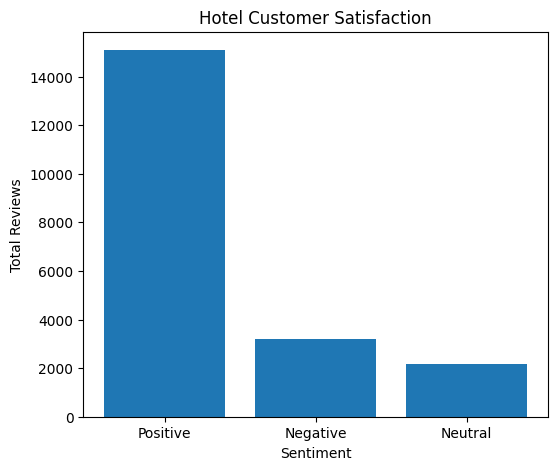

In [14]:
sentiment_summary = hotel_reviews["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    sentiment_summary.index,
    sentiment_summary.values
)

plt.title("Hotel Customer Satisfaction")
plt.xlabel("Sentiment")
plt.ylabel("Total Reviews")

plt.show()


In [15]:

keywords = [
    "room",
    "staff",
    "food",
    "clean",
    "service",
    "location",
    "bed"
]

print("\nService Related Keyword Analysis\n")

for item in keywords:

    total = hotel_reviews["Processed_Review"].str.contains(
        item,
        case=False
    ).sum()

    print(f"{item.capitalize()} : {total}")

print("\nSample Reviews Related to 'service'\n")

print(
    hotel_reviews[
        hotel_reviews["Processed_Review"].str.contains("service")
    ][["Review"]].head()
)



Service Related Keyword Analysis

Room : 17747
Staff : 11915
Food : 5806
Clean : 8711
Service : 6688
Location : 8499
Bed : 6557

Sample Reviews Related to 'service'

                                              Review
2  nice rooms not 4* experience hotel monaco seat...
3  unique, great stay, wonderful time hotel monac...
4  great stay great stay, went seahawk game aweso...
5  love monaco staff husband stayed hotel crazy w...
7  excellent staff, housekeeping quality hotel ch...


In [16]:
positive = (
    hotel_reviews["Sentiment"] == "Positive"
).sum()

neutral = (
    hotel_reviews["Sentiment"] == "Neutral"
).sum()

negative = (
    hotel_reviews["Sentiment"] == "Negative"
).sum()

print("\n========== CUSTOMER SATISFACTION REPORT ==========")

print("Positive Reviews :", positive)
print("Neutral Reviews  :", neutral)
print("Negative Reviews :", negative)

print("\nTotal Reviews :", len(hotel_reviews))

positive_percentage = round((positive / len(hotel_reviews)) * 100, 2)
neutral_percentage = round((neutral / len(hotel_reviews)) * 100, 2)
negative_percentage = round((negative / len(hotel_reviews)) * 100, 2)

print("\nPositive % :", positive_percentage)
print("Neutral %  :", neutral_percentage)
print("Negative % :", negative_percentage)


========== CUSTOMER SATISFACTION REPORT ==========
Positive Reviews : 15093
Neutral Reviews  : 2184
Negative Reviews : 3214

Total Reviews : 20491

Positive % : 73.66
Neutral %  : 10.66
Negative % : 15.68


In [17]:

hotel_reviews.to_csv(
    "Hotel_Customer_Satisfaction_Report.csv",
    index=False
)

print("\nReport Saved Successfully.")


Report Saved Successfully.
